# **1. Perkenalan Dataset**


**Sumber Dataset**:  
Dataset yang saya gunakan adalah Dataset yang saya dapat memalui Kaggle, dapat diakses melalui link berikut; [diabetes-prediction-dataset](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset).

Dataset Diabetes Prediction Dataset merupakan kumpulan data medis dan demografis pasien yang digunakan untuk memprediksi status diabetes (positif atau negatif) berdasarkan riwayat kesehatan mereka. Dataset ini mencakup berbagai fitur penting seperti usia, jenis kelamin, indeks massa tubuh (BMI), riwayat hipertensi, penyakit jantung, riwayat merokok, serta hasil laboratorium berupa kadar HbA1c dan tingkat glukosa darah.

Dalam proyek ini, dataset tersebut akan digunakan untuk membangun model machine learning yang dapat membantu tenaga medis mengidentifikasi pasien berisiko tinggi secara dini serta menyusun rencana perawatan yang tepa


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Pengaturan agar visualisasi rapi
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Dataset yang saya ambil melalui _platform_ Kaggle, saya _download_ dalam bentuk (.csv) file dataset diletakkan langsung di dalam folder yang sama dengan file notebook ini (preprocessing), sehingga pemanggilan data dapat dilakukan secara langsung tanpa berpindah direktori.

Jika data sudah berhasil dimuat ke dalam objek DataFrame Pandas, akan ada inspeksi awal dengan menampilkan beberapa baris pertama data serta memeriksa ringkasan tipe data dan struktur kolomnya. Langkah ini penting untuk memastikan bahwa data terbaca dengan sempurna dan siap dianalisis pada tahap berikutnya.

In [2]:
# Memuat data
df = pd.read_csv('../diabetes_prediction_dataset.csv')

# Cek 5 baris pertama
display(df.head())

# Cek info data
df.info()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, dilakukan eksplorasi awal terhadap dataset untuk memahami karakteristik data, menemukan pola yang mungkin terdapat di dalamnya, serta mengidentifikasi potensi masalah yang dapat memengaruhi proses pemodelan. 

1. Analisis Deskriptif: 
    Berfungsi untuk memperoleh gambaran umum mengenai data, seperti nilai minimum, maksimum, rata-rata, dan penyebaran data pada fitur-fitur numerik, misalnya usia, BMI, dan kadar glukosa darah. Analisis ini membantu memahami kondisi dan karakteristik setiap variabel.
2. Pemeriksaan Kualitas Data: 
    Saya memeriksa apakah terdapat nilai yang hilang (missing values) serta mendeteksi adanya data yang terduplikasi. Langkah ini dilakukan untuk memastikan kualitas dataset tetap terjaga karena data yang tidak lengkap atau terlalu banyak duplikasi dapat memengaruhi performa model yang akan dibangun.
3. Visualisasi Distribusi Target: 
    Saya membuat visualisasi berupa grafik batang untuk melihat distribusi kelas pada variabel target, yaitu diabetes. Melalui visualisasi ini, saya dapat mengetahui apakah jumlah data pada masing-masing kelas seimbang atau terdapat ketimpangan (imbalanced dataset), sehingga dapat menentukan langkah penanganan yang sesuai pada tahap berikutnya.

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


Missing values:
 gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Jumlah data duplikat: 3854


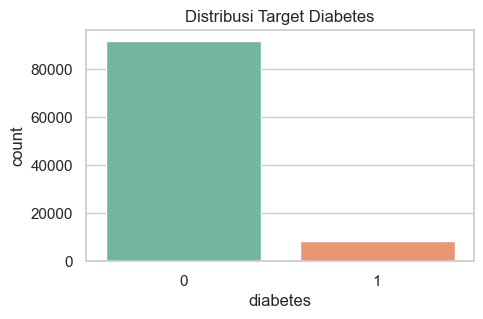

In [3]:
# 1. Cek ringkasan statistik
display(df.describe())

# 2. Cek missing values dan duplikat
print("Missing values:\n", df.isnull().sum())
print("\nJumlah data duplikat:", df.duplicated().sum())

# 3. Visualisasi sederhana distribusi target
plt.figure(figsize=(5,3))
sns.countplot(x='diabetes', data=df, palette='Set2')
plt.title('Distribusi Target Diabetes')
plt.show()

# **5. Data Preprocessing**

Pada tahapan ini dilakukan preprocessing data untuk meningkatkan kualitas dataset sebelum digunakan dalam proses pelatihan model. Langkah pertama adalah menangani missing values pada kolom BMI dan blood glucose level menggunakan metode imputasi median, sehingga data yang kosong dapat terisi tanpa terlalu dipengaruhi oleh nilai ekstrem.

Selanjutnya, data yang terduplikasi dihapus untuk menghindari bias pada model. Setelah itu, dilakukan deteksi dan penanganan outlier pada kolom BMI menggunakan metode IQR Capping, yaitu membatasi nilai yang berada di luar rentang normal agar tidak memberikan pengaruh berlebihan terhadap hasil prediksi.

Tahap berikutnya adalah binning, yaitu mengelompokkan data usia ke dalam beberapa kategori umur dan membentuk fitur baru bernama age_group. Kemudian, data kategorikal seperti gender dan smoking_history diubah menjadi bentuk numerik menggunakan Label Encoding agar dapat diproses oleh algoritma machine learning.

Terakhir, dataset dipisahkan menjadi data latih dan data uji dengan perbandingan 80:20, kemudian dilakukan standarisasi fitur numerik menggunakan StandardScaler. Proses ini bertujuan menyamakan skala nilai antar fitur sehingga model dapat belajar dengan lebih optimal.

In [4]:
# --- 1. MENANGANI DATA KOSONG (MISSING VALUES) ---
print("--- 1. Handling Missing Values ---")
df_filled = df.copy()
df_filled['bmi'] = df_filled['bmi'].fillna(df_filled['bmi'].median())
df_filled['blood_glucose_level'] = df_filled['blood_glucose_level'].fillna(df_filled['blood_glucose_level'].median())
print("Missing values aman diantisipasi dengan metode Imputasi Median.")

# --- 2. MENGHAPUS DATA DUPLIKAT ---
print("\n--- 2. Handling Data Duplikat ---")
df_nodup = df_filled.drop_duplicates().reset_index(drop=True)
print(f"Data duplikat dihapus. Baris menyusut dari {len(df_filled)} menjadi {len(df_nodup)} baris.")

# --- 3. DETEKSI DAN PENANGANAN OUTLIER ---
print("\n--- 3. Handling Outliers ---")
Q1 = df_nodup['bmi'].quantile(0.25)
Q3 = df_nodup['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Capping outlier: Mengubah nilai di luar batas menjadi nilai batas maksimum/minimumnya
df_no_outlier = df_nodup.copy()
df_no_outlier['bmi'] = np.where(df_no_outlier['bmi'] > upper_bound, upper_bound, 
                        np.where(df_no_outlier['bmi'] < lower_bound, lower_bound, df_no_outlier['bmi']))
print("Outlier pada kolom BMI telah ditangani menggunakan metode IQR Capping.")

# --- 4. BINNING (PENGELOMPOKAN DATA) ---
print("\n--- 4. Data Binning ---")
df_binning = df_no_outlier.copy()
# Menggunakan pd.cut untuk membagi kelompok umur
df_binning['age_group'] = pd.cut(df_binning['age'], bins=[0, 25, 60, 100], labels=[0, 1, 2], include_lowest=True)
# Ubah tipe data kelompok umur menjadi integer agar bisa dibaca model
df_binning['age_group'] = df_binning['age_group'].astype(int)
print("Fitur baru 'age_group' berhasil dibuat melalui proses Binning Umur.")

# --- 5. ENCODING DATA KATEGORIKAL ---
print("\n--- 5. Categorical Encoding ---")
df_encoded = df_binning.copy()
le_gender = LabelEncoder()
df_encoded['gender'] = le_gender.fit_transform(df_encoded['gender'])

le_smoking = LabelEncoder()
df_encoded['smoking_history'] = le_smoking.fit_transform(df_encoded['smoking_history'])
print("Encoding data kategorikal 'gender' dan 'smoking_history' sukses.")

# --- MEMISAHKAN FITUR DAN TARGET SEBELUM NORMALISASI ---
X = df_encoded.drop(columns=['diabetes'])
y = df_encoded['diabetes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train = X_train.copy()
X_test = X_test.copy()

# --- 6. NORMALISASI ATAU STANDARISASI FITUR ---
print("\n--- 6. Feature Standarization (Scaling) ---")
scaler = StandardScaler()
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])
print("Standarisasi fitur numerik selesai menggunakan StandardScaler.")

display(X_train.head())

--- 1. Handling Missing Values ---
Missing values aman diantisipasi dengan metode Imputasi Median.

--- 2. Handling Data Duplikat ---
Data duplikat dihapus. Baris menyusut dari 100000 menjadi 96146 baris.

--- 3. Handling Outliers ---
Outlier pada kolom BMI telah ditangani menggunakan metode IQR Capping.

--- 4. Data Binning ---
Fitur baru 'age_group' berhasil dibuat melalui proses Binning Umur.

--- 5. Categorical Encoding ---
Encoding data kategorikal 'gender' dan 'smoking_history' sukses.

--- 6. Feature Standarization (Scaling) ---
Standarisasi fitur numerik selesai menggunakan StandardScaler.


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,age_group
76484,1,0.144164,0,0,0,-0.532977,0.158030,-0.296217,1
31572,0,0.989825,0,0,3,1.013465,-1.427179,-0.296217,2
92017,0,0.144164,0,0,0,0.049471,0.997258,-0.296217,1
31616,1,0.099655,1,0,0,0.309463,-0.681198,-1.421004,1
94106,0,-0.656989,0,0,5,-0.092342,0.904010,1.513222,1
